# Clase 2: Optimizacion y Entrenamiento de Redes Neuronales

## Caso de Estudio: Prediccion de Supervivencia con el Titanic Dataset

**Modulo:** Cientifico de Datos e Inteligencia Artificial Aplicada
**Tecnologias:** Python, TensorFlow, Keras, Scikit-Learn, Matplotlib
**Dataset:** [Titanic - Machine Learning from Disaster (Kaggle)](https://www.kaggle.com/competitions/titanic)

## Objetivo de esta practica

En la Clase 1 construimos una ANN que funcionaba. Ahora vamos a **entrenarla bien**.

Partimos de un modelo baseline y medimos, con evidencia, el impacto de cada decision de entrenamiento:
optimizador -> learning rate -> batch size -> inicializacion -> regularizacion -> callbacks.

Flujo: datos de Kaggle -> baseline -> experimentos comparativos -> modelo final optimizado -> evaluacion.

## 0) Obtener el dataset desde Kaggle

Los datasets **no se versionan en el repositorio**. Cada estudiante los descarga en su entorno.

### Opcion A: descarga manual
1. Crear cuenta en https://www.kaggle.com
2. Entrar a https://www.kaggle.com/competitions/titanic y aceptar las reglas (`Join Competition`).
3. Pestana `Data` -> descargar `train.csv`.
4. Guardarlo en la carpeta `data/` de esta clase: `data/train.csv`.

### Opcion B: API oficial de Kaggle
```bash
pip install kaggle
# Token: https://www.kaggle.com/settings -> API -> Create New Token
# Windows: C:\Users\<usuario>\.kaggle\kaggle.json
# Linux/macOS: ~/.kaggle/kaggle.json   (chmod 600 ~/.kaggle/kaggle.json)
kaggle competitions download -c titanic -p data
```
Luego descomprimir `data/titanic.zip`.

> Recuerda anadir `data/` y `kaggle.json` al `.gitignore`.

In [3]:
%pip install numpy pandas matplotlib 

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.3 MB 12.6 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 24.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 25.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 69.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 40.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- --

In [45]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [6]:
file_path = os.path.join("titanic", "train.csv")

df = pd.read_csv(file_path)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
print("Valores nulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])

Valores nulos por columna:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [10]:
print("Distrubución de la variable objetivo (Survived):")
print(df['Survived'].value_counts())
print("Distribución de la variable objetivo (Survived) en porcentaje (0: no sobrevivió, 1: sobrevivió):")
print(df['Survived'].value_counts(normalize=True) * 100)

Distrubución de la variable objetivo (Survived):
Survived
0    549
1    342
Name: count, dtype: int64
Distribución de la variable objetivo (Survived) en porcentaje (0: no sobrevivió, 1: sobrevivió):
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


### Lectura del EDA

- `Age` y `Embarked` tienen nulos: hay que imputar, no eliminar filas (perderiamos ~20% del dataset).
- `Cabin` tiene demasiados nulos para ser util en este baseline.
- `Name`, `Ticket` y `PassengerId` son identificadores: se descartan para evitar ruido y leakage.
- El target esta moderadamente desbalanceado (~62% / 38%), aceptable sin `class_weight`.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [19]:
target_col = 'Survived'
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', target_col] 

x = df.drop(columns=[ c for c in drop_cols if c in df.columns ])
y = df[target_col].astype('int')

numeroc_cols = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Pclass', 'Sex', 'Embarked']

print("Columnas numéricas:", numeroc_cols)
print("Columnas categóricas:", categorical_cols)
print("Número de muestras:", x.shape[0])
print("Numero de freatures:", x.shape[1])

Columnas numéricas: ['Age', 'SibSp', 'Parch', 'Fare']
Columnas categóricas: ['Pclass', 'Sex', 'Embarked']
Número de muestras: 891
Numero de freatures: 7


In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED, stratify=y)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeroc_cols),
    ('cat', categorical_pipe, categorical_cols)
])

x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

X_train = np.asanyarray(x_train_preprocessed, dtype=np.float32)
X_test = np.asanyarray(x_test_preprocessed, dtype=np.float32)
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()
INPUT_DIM = X_train.shape[1]

print("Número de muestras de entrenamiento:", X_train.shape)
print("Número de muestras de prueba:", X_test.shape)
print("Número de features después del preprocesamiento:", INPUT_DIM)
print("ColumnTransformer transformó las columnas categóricas en:", preprocessor.transformers_[1][1]['onehot'].get_feature_names_out(categorical_cols))

Número de muestras de entrenamiento: (712, 12)
Número de muestras de prueba: (179, 12)
Número de features después del preprocesamiento: 12
ColumnTransformer transformó las columnas categóricas en: ['Pclass_1' 'Pclass_2' 'Pclass_3' 'Sex_female' 'Sex_male' 'Embarked_C'
 'Embarked_Q' 'Embarked_S']


> **Importante:** el preprocesador se ajusta (`fit`) solo con `X_train`. Si se ajustara con todo el
> dataset, la media y la desviacion de test se filtrarian al entrenamiento (**data leakage**).

## 5) Funciones de apoyo para experimentar

Para comparar decisiones de entrenamiento de forma justa necesitamos que **todo lo demas se mantenga igual**:
misma arquitectura, misma semilla, mismas epocas. Estas dos funciones nos dan esa base controlada.

In [38]:
def build_model(
        optimizer='adam',
        hidden=(16, 8),
        activation='relu',
        initializer='glorot_uniform',
        dropout=0.0,
        l2=0.0,
        batchbnorm=False,
        seed=SEED
    ):
    """Contruye un ANN binario para clasificación con Keras."""
    keras.utils.set_random_seed(seed)
    model = keras.Sequential(name='ann_binary_classification_titanic')
    model.add(keras.Input(shape=(INPUT_DIM,)))

    for units in hidden:
        model.add(layers.Dense(
            units,
            activation=None if batchbnorm else activation,
            kernel_initializer=initializer,
            kernel_regularizer=keras.regularizers.l2(l2) if l2 > 0 else None,
        ))
        if batchbnorm:
            model.add(layers.BatchNormalization())
            model.add(layers.Activation(activation))
        if dropout > 0:
            model.add(layers.Dropout(dropout),seed=seed)

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Opcion 1:

In [71]:
def run_exp(label, epochs=80, batch_size=32, model_kwargs=None, fit_kwargs=None):
    model = build_model(**model_kwargs or {})

    history = model.fit(
        X_train, y_train_np,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        **(fit_kwargs or {})
    )
    

    best_val_loss = float(np.min(history.history['val_loss']))
    best_val_acc = float(np.max(history.history['val_accuracy']))
    print(f"{label}: Mejor val_loss={best_val_loss:.4f}, Mejor val_accuracy={best_val_acc:.4f}")
    return {label: {'model': model, 'history': history, 'best_val_loss': best_val_loss, 'best_val_acc': best_val_acc}}


Opcion 2:

In [62]:
from tqdm.keras import TqdmCallback

def run_exp_tqdm(label, epochs=80, batch_size=32, model_kwargs=None, fit_kwargs=None):
    model = build_model(**(model_kwargs or {}))

    fit_options = dict(fit_kwargs or {})
    existing_callbacks = list(fit_options.pop("callbacks", []))

    history = model.fit(
        X_train,
        y_train_np,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=existing_callbacks + [TqdmCallback(verbose=1)],
        **fit_options
    )

    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_acc = float(np.max(history.history["val_accuracy"]))

    print(
        f"{label}: Mejor val_loss={best_val_loss:.4f}, "
        f"Mejor val_accuracy={best_val_acc:.4f}"
    )

    return {
        label: {
            "model": model,
            "history": history,
            "best_val_loss": best_val_loss,
            "best_val_acc": best_val_acc,
        }
    }


In [72]:
baseline = run_exp_tqdm(
    'Baseline (Adam, lr=0.001)',
    epochs=80,
    batch_size=32
)
baseline['Baseline (Adam, lr=0.001)']['model'].summary()

100%|██████████| 80/80 [00:11<00:00,  7.03epoch/s, accuracy=0.863, loss=0.341, val_accuracy=0.769, val_loss=0.521]

Baseline (Adam, lr=0.001): Mejor val_loss=0.4599, Mejor val_accuracy=0.7972


Model: "ann_binary_classification_titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061 (4.15 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 708 (2.77 KB)

In [73]:
baseline = run_exp(
    'Baseline (Adam, lr=0.001)',
    epochs=80,
    batch_size=32
)
baseline['Baseline (Adam, lr=0.001)']['model'].summary()

Baseline (Adam, lr=0.001): Mejor val_loss=0.4599, Mejor val_accuracy=0.7972


Model: "ann_binary_classification_titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061 (4.15 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 708 (2.77 KB)

In [77]:
def _flatten_results(results):
    flattened = []
    for result in results:
        if len(result) != 1:
            raise ValueError('Cada resultado debe contener exactamente una configuracion.')
        label, values = next(iter(result.items()))
        flattened.append({'label': label, **values})
    return flattened


def plot_history(results, title, metric='loss'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for res in _flatten_results(results):
        history = res['history'].history
        axes[0].plot(history[metric], label=res['label'])
        axes[1].plot(history['val_' + metric], label=res['label'])

    axes[0].set_title(f'{title} - {metric} (train)')
    axes[1].set_title(f'{title} - {metric} (validacion)')
    for ax in axes:
        ax.set_xlabel('Epoca')
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def comparison_table(results):
    flattened = _flatten_results(results)
    return (pd.DataFrame([{'Configuracion': res['label'],
                           'Val loss (min)': round(res['best_val_loss'], 4),
                           'Val accuracy (max)': round(res['best_val_acc'], 4)}
                          for res in flattened])
            .sort_values('Val loss (min)')
            .reset_index(drop=True))

## 7) Descenso de gradiente y optimizadores

El entrenamiento actualiza los pesos siguiendo el gradiente de la perdida:

$$
w \leftarrow w - \eta \frac{\partial L}{\partial w}
$$

**Backpropagation** es el algoritmo que calcula esos gradientes hacia atras, capa por capa.
El **optimizador** decide como se usa el gradiente:

| Optimizador | Idea central |
|---|---|
| `SGD` | Aplica la regla base tal cual |
| `SGD + Momentum` | Acumula la direccion previa: atraviesa zonas planas |
| `RMSprop` | Learning rate adaptativo por parametro |
| `Adam` | Momentum + RMSprop: el default razonable |

SGD (lr=0.01): Mejor val_loss=0.4723, Mejor val_accuracy=0.8042
SGD + Momentum (0.9): Mejor val_loss=0.4678, Mejor val_accuracy=0.8042
RMSprop (lr=0.001): Mejor val_loss=0.4606, Mejor val_accuracy=0.7972
Adam (lr=0.001): Mejor val_loss=0.4599, Mejor val_accuracy=0.7972


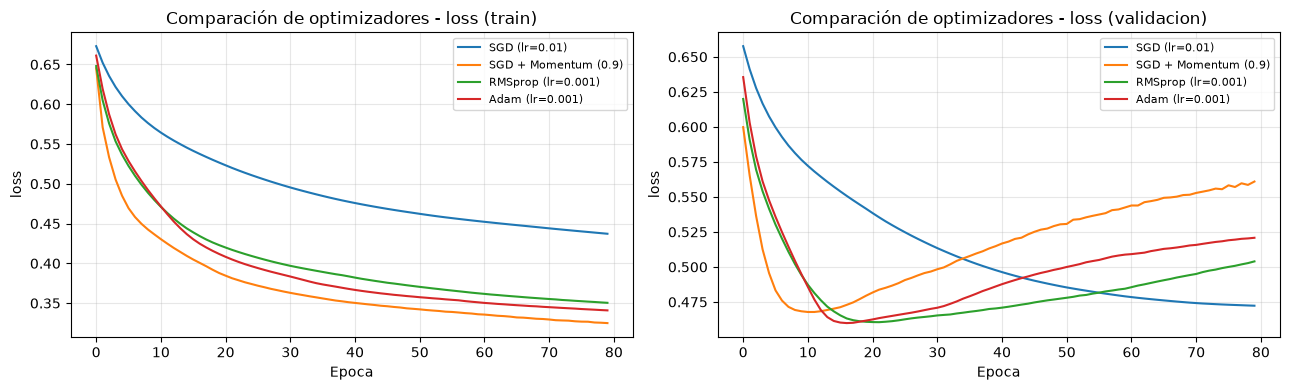

,Configuracion,Val loss (min),Val accuracy (max)
0,Adam (lr=0.001),0.4599,0.7972
1,RMSprop (lr=0.001),0.4606,0.7972
2,SGD + Momentum (0.9),0.4678,0.8042
3,SGD (lr=0.01),0.4723,0.8042


In [78]:
opt_result = [
    run_exp('SGD (lr=0.01)',
                   model_kwargs={'optimizer': keras.optimizers.SGD(learning_rate=0.01)}),
    run_exp('SGD + Momentum (0.9)',
                   model_kwargs={'optimizer': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)}),
    run_exp('RMSprop (lr=0.001)',
                   model_kwargs={'optimizer': keras.optimizers.RMSprop(learning_rate=0.001)}),
    run_exp('Adam (lr=0.001)',
                   model_kwargs={'optimizer': keras.optimizers.Adam(learning_rate=0.001)}),
]

plot_history(opt_result, title='Comparación de optimizadores', metric='loss')
comparison_table(opt_result)

### Como leer esta comparativa

- **SGD puro** baja la loss de forma lenta y suave: necesita mas epocas o un learning rate mayor.
- **Momentum** acelera claramente a SGD con el mismo learning rate.
- **RMSprop y Adam** convergen rapido en las primeras epocas, pero suelen empezar a sobreajustar antes.
- La curva que importa para decidir es la de **validacion**, no la de train.

## 8) Learning rate: el hiperparametro mas critico

| Learning rate | Sintoma |
|---|---|
| Muy alto | La loss oscila, sube o se vuelve `NaN` |
| Muy bajo | La loss baja demasiado lento, no llega a converger |
| Adecuado | Baja rapido al inicio y luego se estabiliza |

Adam lr=0.5: Mejor val_loss=0.6760, Mejor val_accuracy=0.6014


 86%|████████▋ | 69/80 [10:16<01:38,  8.94s/epoch, accuracy=0.814, loss=0.446, val_accuracy=0.797, val_loss=0.475]






Adam lr=0.05: Mejor val_loss=0.4589, Mejor val_accuracy=0.8252
Adam lr=0.001: Mejor val_loss=0.4599, Mejor val_accuracy=0.7972
Adam lr=1e-05: Mejor val_loss=0.6444, Mejor val_accuracy=0.6923


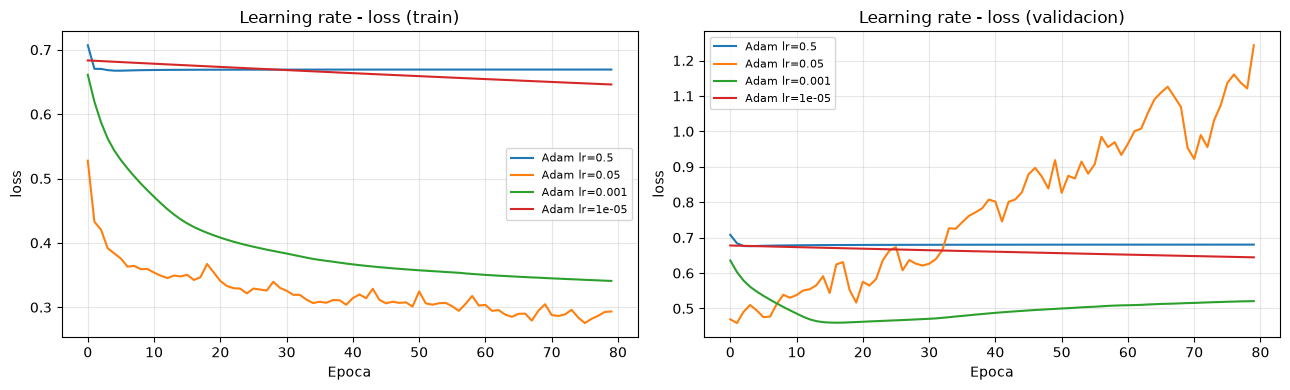

,Configuracion,Val loss (min),Val accuracy (max)
0,Adam lr=0.05,0.4589,0.8252
1,Adam lr=0.001,0.4599,0.7972
2,Adam lr=1e-05,0.6444,0.6923
3,Adam lr=0.5,0.6760,0.6014


In [80]:
# 8.1) Barrido de learning rate con Adam
lr_results = [
    run_exp(f'Adam lr={lr}',
                   model_kwargs={'optimizer': keras.optimizers.Adam(learning_rate=lr)})
    for lr in [0.5, 0.05, 0.001, 0.00001]
]

plot_history(lr_results, 'Learning rate', metric='loss')
comparison_table(lr_results)

## 9) Schedulers: learning rate que cambia en el tiempo

La estrategia es dar **pasos grandes al inicio** para avanzar rapido y **pasos pequenos al final**
para afinar sin saltarse el minimo.

- `ExponentialDecay`: decae de forma continua segun los pasos ejecutados.
- `PiecewiseConstantDecay`: escalones definidos manualmente.
- `ReduceLROnPlateau`: reduce el lr **solo** cuando `val_loss` deja de mejorar (callback reactivo).

## 10) Batch size

Define cuantas muestras se procesan antes de cada actualizacion de pesos.

| Batch size | Efecto |
|---|---|
| Pequeno (8-32) | Mas ruido en el gradiente, a veces mejor generalizacion, mas lento por epoca |
| Mediano (32-128) | Equilibrio habitual |
| Grande (256+) | Rapido y estable, riesgo de converger a minimos que generalizan peor |

## 11) Inicializacion de pesos

Si todos los pesos inician en el mismo valor, todas las neuronas calculan lo mismo y la red nunca
se diferencia (problema de simetria). Una buena inicializacion mantiene la varianza de la senal
entre capas.

| Inicializador | Recomendado con |
|---|---|
| `glorot_uniform` (Xavier) | `tanh`, `sigmoid` — es el default de Keras |
| `he_normal` | `relu` y variantes |
| `zeros` | **Nunca**: rompe el entrenamiento (se incluye solo para demostrarlo) |

## 12) Regularizacion: controlar el overfitting

Forzamos primero el overfitting con una red sobredimensionada y luego aplicamos cada tecnica.

### L2 (weight decay)
$$
L_{total} = L + \lambda \sum w^2
$$
Penaliza pesos grandes. L1 (`\lambda \sum |w|`) tiende a llevar pesos a cero.

### Dropout
Desactiva aleatoriamente un porcentaje de neuronas en cada paso de entrenamiento (valores tipicos 0.2-0.5).
En inferencia se desactiva solo.

### Batch Normalization
Normaliza las activaciones por mini-batch: estabiliza el entrenamiento y permite learning rates mas altos.

### Senal de overfitting

En la red grande sin regularizar la `loss` de train sigue bajando mientras la `val_loss` empieza a
**subir**: el modelo esta memorizando el conjunto de entrenamiento. Las variantes regularizadas
mantienen la brecha entre train y validacion mucho mas estrecha.

## 13) Callbacks: no elegir las epocas a mano

| Callback | Funcion |
|---|---|
| `EarlyStopping` | Detiene el entrenamiento cuando `val_loss` deja de mejorar |
| `ModelCheckpoint` | Guarda el mejor modelo segun la metrica de validacion |
| `ReduceLROnPlateau` | Reduce el learning rate cuando la mejora se estanca |

La practica correcta es entrenar con un limite alto de epocas y dejar que `EarlyStopping`
con `restore_best_weights=True` recupere el mejor punto.

## Como leer estas graficas (diagnostico)

| Situacion | Train | Validacion | Diagnostico | Accion |
|---|---|---|---|---|
| Ambas bajan y quedan cercanas | Loss baja | Loss baja | Buen ajuste | Consolidar |
| Train baja, validacion sube | Loss baja | Loss sube | **Overfitting** | Dropout, L2, EarlyStopping, mas datos |
| Ambas se quedan altas | Loss alta | Loss alta | **Underfitting** | Mas capas/neuronas, mas epocas, mayor lr |
| La loss oscila fuerte | Inestable | Inestable | Learning rate alto | Reducir lr o usar scheduler |
| Validacion mejor que train | - | - | Dropout activo en train | Normal, confirmar en test |

### Matriz de confusion (Test)
- Filas: clase real. Columnas: clase predicha.
- Diagonal principal: aciertos. Fuera de la diagonal: errores.
- En Titanic interesa mirar los **falsos negativos** (pasajeros que sobrevivieron y el modelo
  clasifico como no sobrevivientes): si el costo de ese error es alto, conviene bajar el umbral de 0.5.

### Linea del punto rojo en la curva de Loss
Marca la epoca con `val_loss` minima, que es el modelo que `EarlyStopping` restauro con
`restore_best_weights=True`. Las epocas posteriores solo estaban memorizando.

## Actividad rapida

1. Cambia el optimizador del modelo final a `SGD(learning_rate=0.01, momentum=0.9)` y compara el
   accuracy en test. Documenta cual gano y por que crees que fue asi.
2. Ajusta el umbral de decision (`0.3`, `0.4`, `0.6`) y analiza como cambian precision y recall
   de la clase `Sobrevivio`.
3. Reduce `patience` de `EarlyStopping` a 3 y explica que riesgo introduce detenerse demasiado pronto.
4. Prueba `dropout=0.6` y justifica con las curvas si ayuda o si provoca underfitting.
5. Crea una variable nueva (por ejemplo `FamilySize = SibSp + Parch + 1`), reentrena el modelo final
   y reporta si el aporte de la variable supera el de los ajustes de optimizacion.

## Conclusion de la clase

La arquitectura define **que puede aprender** la red; la optimizacion define **si realmente lo aprende**.
Un baseline con buenas decisiones de entrenamiento supera a una red grande mal entrenada.